In [374]:
%pip install numpy matplotlib scipy pandas

Note: you may need to restart the kernel to use updated packages.


In [375]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import pandas as pd
from IPython.display import display
import openpyxl

# Входные данные

In [376]:
Tа_полн = 288   # K
Pа_полн = 1.013 * 10**5  # Па
G_в = 58.7  # кг/с
π_к_полн = 18.2  # Степень повышения давления в компрессоре
n = 8600  # об/мин

R_в = 287.4  # Дж/(кг*К)
k = 1.4  # показатель адиабаты для воздуха
# Дж/(кг*К) удельная теплоемкость при постоянном давлении для воздуха
c_p = 1006

# Предварительный расчет проточной части по средней линии тока

In [377]:
# Dk = const

d1_отн = 0.4    # Относительный диаметр втулки первой ступени
c_а1_отн = 0.45   # Коэффициент расхода первой ступени
с_а_отн = 0.3   # Коэффициент расхода для последней ступени примем
Hт_ср_отн = 0.3   # Коэффициент напора в средних ступенях
R_ср1 = 0.5   # Степень реактивности
H_т1 = 0.2   # Коэффициент напора первой ступени

# Первое приближение

In [378]:
n = n / (60 / (2 * math.pi))  # Преобразуем обороты в радианы в секунду
print(f" n = {n}")

 n = 900.589894029074


In [379]:
def a_кр(k, R, T):
    return math.sqrt((2*k/(k+1))*R*T)

def U_k(G_в, n, c_а1_отн, ρ1_полн, d1_отн):
    return math.cbrt((G_в * n**2)/(math.pi * c_а1_отн * ρ1_полн * (1 - d1_отн**2)))

def ε_gdf(k, λ):
    return (1 - (k-1)/(k+1)*λ**2)**(1/(k-1))

def σ_gdf(ξ, k, ε, λ):
    return (1 / (1 + ξ * (k/(k+1)) * ε * λ**2))

def radius_отн(d_отн):
    return math.sqrt( (1 + d_отн**2) / 2)

def q_gdf(k, λ):
    return ((k+1)/2)**(1/(k-1)) * λ * (1 - (k-1)/(k+1)*λ**2)**(1/(k-1))

def F_tube(G_в, R_в, T, β, P, q):
    return (G_в * math.sqrt(R_в * T)) / (β * P * q)

In [380]:
# Определим адиабатический КПД
η_пол = 0.92 # Политропический КПД компрессора из рис.1
η_к_полн = ((π_к_полн)**((k-1)/k)-1) / ((π_к_полн)**((k-1)/(k*η_пол))-1)

In [381]:
# Пренебрегая теплообменом в трубках:
T1_полн = Tа_полн

# Температура на выходе из ЛА компрессора
Tk_полн = Tа_полн * (1 + ((π_к_полн**((k-1)/k)-1) / η_к_полн))
T2_полн = Tk_полн

# Критическая скорость звука во входном и выходном патрубках
a_кр_вх = a_кр(k, R_в, Tа_полн)
a_кр_вых = a_кр(k, R_в, Tk_полн)

# Плотность рабочего тела по заторможенным параметрам
ρ1_полн = Pа_полн / (Tа_полн * R_в)

# Окружная скорость конца рабочей лопатки
U_k1 = U_k(G_в, n, c_а1_отн, ρ1_полн, d1_отн)
print(f"U_k1 = {U_k1:.2f} м/с")

for i in range(3):      # Цикл для трех приближений
    # Осевая скорость на переферии РК
    c_а1 = c_а1_отн * U_k(G_в, n, c_а1_отн, ρ1_полн, d1_отн)

    # Значение абсолютной скорости на выходе из входного патрубка и на входе в выходной патрубок
    c_вх = U_k1 * c_а1_отн
    c_вых = U_k1 * с_а_отн

    # Приведенные скорости в данных сечениях
    λ_вх = c_вх / a_кр_вх
    λ_вых = c_вых / a_кр_вых

    # Коэффициент потерь полного давления во входном и выходном патрубках
    ξ_вх = 0.05     # Для входного патрубка
    ξ_вых = 0.15    # Для выходного патрубка

    # ГДФ плотности для входного и выходного патрубков
    ε_вх = ε_gdf(k, λ_вх)
    ε_вых = ε_gdf(k, λ_вых)

    # Коэффициенты сохранения полного давления во входном и выходном патрубках
    σ_вх = σ_gdf(ξ_вх, k, ε_вх, λ_вх)
    σ_вых = σ_gdf(ξ_вых, k, ε_вых, λ_вых)

    # Полные давления на входе и выходе из лопаточного аппарата
    P1_полн = σ_вх * Pа_полн

    # Средний радиус на входе в первую степень
    r_ср1_отн = radius_отн(d1_отн)

    # Безразмерная окружная составляющая абсолютной скорости на входе
    c_1u_отн = r_ср1_отн * (1 - R_ср1) - (H_т1 / (2 * r_ср1_отн))

    # Абсолютная скорость: 
    c1 = U_k1 * math.sqrt(c_а1_отн**2 + c_1u_отн**2)

    # Приведенная скорость:
    λ1 = c1 / a_кр_вх

    # ГДФ плотности
    ε = (1 - ((k-1)/(k+1)) * λ1**2)**(1/(k-1))

    # Плотность рабочего тела перед РК
    ρ1 = (P1_полн / (R_в * T1_полн)) * ε

    # Перерасчет окружной скорости конца рабочей лопатки
    U_k1 = U_k(G_в, n, c_а1_отн, ρ1, d1_отн)
    print(f"U_k1 = {U_k1:.2f} м/с")

U_k1 = 319.97 м/с
U_k1 = 333.63 м/с
U_k1 = 334.88 м/с
U_k1 = 335.00 м/с


In [382]:
print(f"""
η_пол = {η_пол:.3f} - политропический КПД компрессора
η_к_полн = {η_к_полн:.4f} - адиабатический КПД компрессора

T1_полн = {T1_полн:.2f} K - температура на входе в ЛА
Tk_полн = {Tk_полн:.2f} K - температура на выходе из ЛА
T2_полн = {T2_полн:.2f} K - температура на входе в следующий элемент

a_кр_вх = {a_кр_вх:.2f} м/с - критическая скорость звука во входном патрубке
a_кр_вых = {a_кр_вых:.2f} м/с - критическая скорость звука в выходном патрубке

ρ1_полн = {ρ1_полн:.4f} кг/м³ - плотность по заторможенным параметрам

U_k1 = {U_k1:.2f} м/с - окружная скорость конца рабочей лопатки

c_а1 = {c_а1:.2f} м/с - осевая скорость на периферии РК
c_вх = {c_вх:.2f} м/с - абсолютная скорость на входе во входной патрубок
c_вых = {c_вых:.2f} м/с - абсолютная скорость на выходе из выходного патрубка

λ_вх = {λ_вх:.4f} - приведённая скорость во входном патрубке
λ_вых = {λ_вых:.4f} - приведённая скорость в выходном патрубке

ξ_вх = {ξ_вх:.3f} - коэффициент потерь полного давления во входном патрубке
ξ_вых = {ξ_вых:.3f} - коэффициент потерь полного давления в выходном патрубке

ε_вх = {ε_вх:.4f} - ГДФ плотности во входном патрубке
ε_вых = {ε_вых:.4f} - ГДФ плотности в выходном патрубке

σ_вх = {σ_вх:.4f} - коэффициент сохранения полного давления во входном патрубке
σ_вых = {σ_вых:.4f} - коэффициент сохранения полного давления в выходном патрубке

P1_полн = {P1_полн:.2f} Па - полное давление на входе в РК

r_ср1_отн = {r_ср1_отн:.4f} - относительный средний радиус на входе в первую ступень

c_1u_отн = {c_1u_отн:.4f} - безразмерная окружная составляющая абсолютной скорости

c1 = {c1:.2f} м/с - абсолютная скорость перед РК
λ1 = {λ1:.4f} - приведённая скорость перед РК

ε = {ε:.4f} - ГДФ плотности перед РК

ρ1 = {ρ1:.4f} кг/м³ - плотность рабочего тела перед РК
""")


η_пол = 0.920 - политропический КПД компрессора
η_к_полн = 0.8829 - адиабатический КПД компрессора

T1_полн = 288.00 K - температура на входе в ЛА
Tk_полн = 709.12 K - температура на выходе из ЛА
T2_полн = 709.12 K - температура на входе в следующий элемент

a_кр_вх = 310.75 м/с - критическая скорость звука во входном патрубке
a_кр_вых = 487.61 м/с - критическая скорость звука в выходном патрубке

ρ1_полн = 1.2239 кг/м³ - плотность по заторможенным параметрам

U_k1 = 335.00 м/с - окружная скорость конца рабочей лопатки

c_а1 = 143.99 м/с - осевая скорость на периферии РК
c_вх = 150.70 м/с - абсолютная скорость на входе во входной патрубок
c_вых = 100.46 м/с - абсолютная скорость на выходе из выходного патрубка

λ_вх = 0.4849 - приведённая скорость во входном патрубке
λ_вых = 0.2060 - приведённая скорость в выходном патрубке

ξ_вх = 0.050 - коэффициент потерь полного давления во входном патрубке
ξ_вых = 0.150 - коэффициент потерь полного давления в выходном патрубке

ε_вх = 0.9049 - ГД

In [383]:
# Значение абсолютной скорости на выходе из входного патрубка и на входе в выходной патрубок
c_вх = U_k1 * c_а1_отн
c_вых = U_k1 * с_а_отн

# Приведенные скорости в данных сечениях
λ_вх = c_вх / a_кр_вх
λ_вых = c_вых / a_кр_вых

# Коэффициент потерь полного давления во входном и выходном патрубках
ξ_вх = 0.05     # Для входного патрубка
ξ_вых = 0.15    # Для выходного патрубка

# ГДФ плотности для входного и выходного патрубков
ε_вх = ε_gdf(k, λ_вх)
ε_вых = ε_gdf(k, λ_вых)

# Коэффициенты сохранения полного давления во входном и выходном патрубках
σ_вх = (1 / (1 + ξ_вх * (k/(k+1)) * ε_вх * λ_вх**2))
σ_вых = (1 - ξ_вых * (k/(k+1)) * ε_вых * λ_вых**2)

# Полные давления на входе и выходе из лопаточного аппарата
P1_полн = σ_вх * Pа_полн
P2_полн = Pа_полн * π_к_полн / σ_вых

# Степень повышения полного давления лопаточного аппарата
π_ла_полн = P2_полн / P1_полн
π_к_полн = π_ла_полн * (σ_вых * σ_вх)

# КПД лопаточного аппарата
η_ла = σ_вых * σ_вх  # Должно быть 1

# Коэффициент C определяется из графика на рис. 7
C = 0.98  # Надо написать функцию для определения C по графику, а не брать константное значение
# !!!!!!!!
# !!!!!!!!

η_ла_полн = η_к_полн / C
η_к_полн = η_ла_полн * ((π_к_полн**((k-1)/k)-1)/(π_ла_полн**((k-1)/k)-1))


β = math.sqrt((2*k)/(k+1)) * (2 / (k+1))**(1/(k-1))

# Приведенная плотность потока массы
q_вх = q_gdf(k, λ_вх)
q_вых = q_gdf(k, λ_вых)
# Кольцевые площади на выходе из входного патрубка и на входе в выходной патрубок
F_вх = F_tube(G_в, R_в, T1_полн, β, P1_полн, q_вх)
F_вых = F_tube(G_в, R_в, T2_полн, β, P2_полн, q_вых)

# Наружный диаметр ротора:
D_к1 = 2 * U_k1 / n

# Внутренний диаметр
D_вт1 = D_к1 * d1_отн

# Средний диаметр
D_ср1 = D_к1 * r_ср1_отн

# Высота лопатки РК 1-й ступени:
h_1 = (1/2) * D_к1 * (1 - d1_отн)

# Диаметр втулки лопаток последнйей ступени:
D_вт_n = math.sqrt(D_к1**2 - ((4 * F_вых) / math.pi))

# Относительный диаметр втулки рабочего колеса последней ступени:
d_n_отн = D_вт_n / D_к1

# Высота лопаток последней ступени:
h_n = (1/2) * D_к1 * (1 - d_n_отн)

# Окружная скорость концов рабочих лопаток "средней" ступени:
# Теоретический напор "средней" ступени:
Hт_ср = Hт_ср_отн * (U_k1**2)

# Адиабатический напор компрессора по параметрам затарможенного потока
H_ад_к_полн = (k*R_в)/(k-1) * Tа_полн*((π_к_полн ** ((k-1)/k))-1)

# Сумма теоретических напоров по ступеням:
H_тк = H_ад_к_полн / η_к_полн

# Число ступеней компрессора:
z = H_тк / Hт_ср
print(f"z = {z} Не округленное")

z = math.ceil(z)
print(f"z = {z}")

print(f"η_ла = {η_ла}")
print(f"π_к_полн = {π_к_полн}")

z = 12.392299547954384 Не округленное
z = 13
η_ла = 0.99019899738749
π_к_полн = 18.200000000000003


In [384]:
print(f"""
c_вх = {c_вх:.2f} м/с - абсолютная скорость на выходе из входного патрубка
c_вых = {c_вых:.2f} м/с - абсолютная скорость на входе в выходной патрубок

λ_вх = {λ_вх:.4f} - приведённая скорость во входном патрубке
λ_вых = {λ_вых:.4f} - приведённая скорость в выходном патрубке

ξ_вх = {ξ_вх:.3f} - коэффициент потерь полного давления во входном патрубке
ξ_вых = {ξ_вых:.3f} - коэффициент потерь полного давления в выходном патрубке

ε_вх = {ε_вх:.4f} - ГДФ плотности во входном патрубке
ε_вых = {ε_вых:.4f} - ГДФ плотности в выходном патрубке

σ_вх = {σ_вх:.4f} - коэффициент сохранения полного давления во входном патрубке
σ_вых = {σ_вых:.4f} - коэффициент сохранения полного давления в выходном патрубке

P1_полн = {P1_полн:.2f} Па - полное давление на входе в лопаточный аппарат
P2_полн = {P2_полн:.2f} Па - полное давление на выходе из лопаточного аппарата

π_ла_полн = {π_ла_полн:.4f} - степень повышения полного давления в ЛА
π_к_полн = {π_к_полн:.4f} - степень повышения полного давления компрессора

η_ла = {η_ла:.4f} - КПД лопаточного аппарата
η_ла_полн = {η_ла_полн:.4f} - полный КПД лопаточного аппарата
η_к_полн = {η_к_полн:.4f} - полный КПД компрессора

C = {C:.3f} - коэффициент из графика

β = {β:.4f} - коэффициент расходной функции

q_вх = {q_вх:.4f} - приведённая плотность потока массы во входном патрубке
q_вых = {q_вых:.4f} - приведённая плотность потока массы в выходном патрубке

F_вх = {F_вх:.5f} м² - кольцевая площадь на выходе из входного патрубка
F_вых = {F_вых:.5f} м² - кольцевая площадь на входе в выходной патрубок

D_к1 = {D_к1:.4f} м - наружный диаметр ротора
D_вт1 = {D_вт1:.4f} м - внутренний диаметр ротора
D_ср1 = {D_ср1:.4f} м - средний диаметр

h_1 = {h_1:.4f} м - высота лопаток первой ступени

D_вт_n = {D_вт_n:.4f} м - диаметр втулки последней ступени
d_n_отн = {d_n_отн:.4f} - относительный диаметр втулки последней ступени

h_n = {h_n:.4f} м - высота лопаток последней ступени

Hт_ср = {Hт_ср:.2f} Дж/кг - теоретический напор средней ступени

H_ад_к_полн = {H_ад_к_полн:.2f} Дж/кг - адиабатический напор компрессора

H_тк = {H_тк:.2f} Дж/кг - суммарный теоретический напор по ступеням

z = {z} - число ступеней компрессора
""")


c_вх = 150.75 м/с - абсолютная скорость на выходе из входного патрубка
c_вых = 100.50 м/с - абсолютная скорость на входе в выходной патрубок

λ_вх = 0.4851 - приведённая скорость во входном патрубке
λ_вых = 0.2061 - приведённая скорость в выходном патрубке

ξ_вх = 0.050 - коэффициент потерь полного давления во входном патрубке
ξ_вых = 0.150 - коэффициент потерь полного давления в выходном патрубке

ε_вх = 0.9048 - ГДФ плотности во входном патрубке
ε_вых = 0.9824 - ГДФ плотности в выходном патрубке

σ_вх = 0.9938 - коэффициент сохранения полного давления во входном патрубке
σ_вых = 0.9963 - коэффициент сохранения полного давления в выходном патрубке

P1_полн = 100674.77 Па - полное давление на входе в лопаточный аппарат
P2_полн = 1850416.66 Па - полное давление на выходе из лопаточного аппарата

π_ла_полн = 18.3801 - степень повышения полного давления в ЛА
π_к_полн = 18.2000 - степень повышения полного давления компрессора

η_ла = 0.9902 - КПД лопаточного аппарата
η_ла_полн = 0.9009 - 

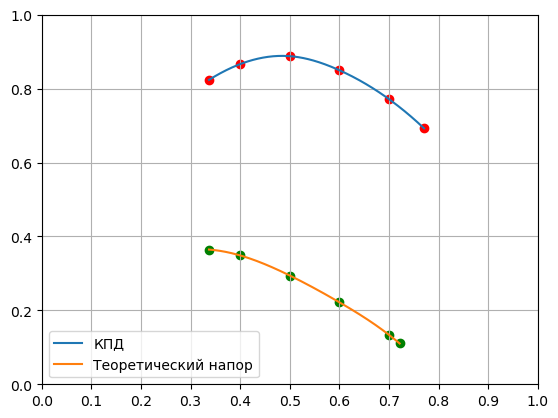

In [385]:
# Ваши точки
x = np.array([0.337091988131, 0.4, 0.5, 0.6,0.7, 0.770588235294])
y = np.array([0.82371541502, 0.866403, 0.88774703, 0.849604743, 0.771343873, 0.692490118577])

x1 = np.array([0.337091988131, 0.4, 0.5, 0.6,0.7, 0.721379310345])
y1 = np.array([0.36446601942, 0.34854368932, 0.294174757282, 0.221747572816, 0.13360824742, 0.11038026721])

# Создаем более плотную сетку X для плавности
x_smooth = np.linspace(x.min(), x.max(), 300)
spline = make_interp_spline(x, y, k=3) # k=3 — кубический сплайн
y_smooth = spline(x_smooth)

x1_smooth = np.linspace(x1.min(), x1.max(), 300)
spline = make_interp_spline(x1, y1, k=3) # k=3 — кубический сплайн
y1_smooth = spline(x1_smooth)

plt.plot(x_smooth, y_smooth, label='КПД')
plt.scatter(x, y, color='red')
plt.plot(x1_smooth, y1_smooth, label='Теоретический напор')
plt.scatter(x1, y1, color='green')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xticks(np.arange(0, 1.1, 0.1))  # Установка делений по оси X с шагом 0.1
plt.yticks(np.arange(0, 1.1, 0.2))  # Установка делений по оси Y с шагом 0.2
plt.grid(True) # Добавление сетки
plt.legend()
plt.show()


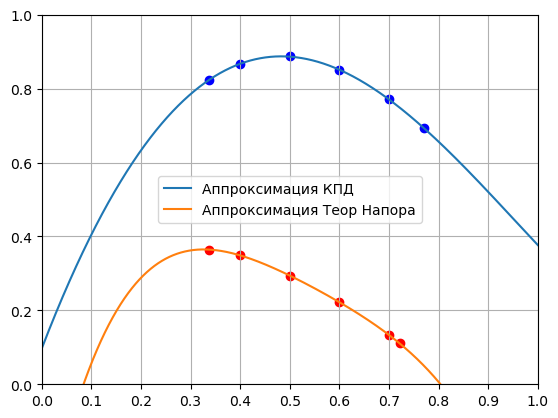

In [386]:
# Точки
x_η_dots = np.array([0.337091988131, 0.4, 0.5, 0.6,0.7, 0.770588235294])       # точки по оси X для теоретического напора
η_dots = np.array([0.82371541502, 0.866403, 0.88774703, 0.849604743, 0.771343873, 0.692490118577])      # точки по оси Y для теоретического напора

x_Hт_dots = np.array([0.337091988131, 0.4, 0.5, 0.6,0.7, 0.721379310345])    # точки по оси X для КПД
Hт_dots = np.array([0.36446601942, 0.34854368932, 0.294174757282, 0.221747572816, 0.13360824742, 0.11038026721]) # точки по оси Y для КПД

# аппроксимация полиномом степени stepen
stepen = 4
coeffs = np.polyfit(x_Hт_dots, Hт_dots, stepen)
poly = np.poly1d(coeffs)
coeffs1 = np.polyfit(x_η_dots, η_dots, stepen)
poly1 = np.poly1d(coeffs1)

smoothness = 100000
x_Hт_dots_smooth = np.linspace(0, 1, smoothness)
Hт_dots_smooth = poly(x_Hт_dots_smooth)
x_η_dots_smooth = np.linspace(0, 1, smoothness)
η_dots_smooth = poly1(x_η_dots_smooth)

plt.plot(x_η_dots_smooth, η_dots_smooth, label="Аппроксимация КПД")
plt.plot(x_Hт_dots_smooth, Hт_dots_smooth, label="Аппроксимация Теор Напора")
plt.scatter(x_Hт_dots, Hт_dots, color="red")
plt.scatter(x_η_dots, η_dots, color="blue")
plt.xlim(0,1)
plt.ylim(0,1)
plt.xticks(np.arange(0, 1.1, 0.1))  # Установка делений по оси X с шагом 0.1
plt.yticks(np.arange(0, 1.1, 0.2))  # Установка делений по оси Y с шагом 0.2
plt.grid(True) # Добавление сетки
plt.legend()
plt.show()

In [387]:
Hт_x_line = x_Hт_dots_smooth    # Координаты X для линии теоретического напора
Hт_y_line = Hт_dots_smooth      # Координаты Y для линии теоретического напора
η_x_line = x_η_dots_smooth      # Координаты X для линии КПД
η_y_line = η_dots_smooth        # Координаты Y для линии КПД

N = z   # Число ступеней компрессора
N_list = np.linspace(1, N, N)   # Массив от 1 до N для итерации по ступеням

Hт_x_result = []
Hт_отн_result = []

c_a_отн = np.linspace(c_а1_отн, с_а_отн, N) # Линейно изменяющийся коэффициент расхода от первой до последней ступени

In [388]:
def find_nearest(c_a_отн, x_line, y_line):
    x_result = []
    y_result = []

    for i in range(len(c_a_отн)):
        index = np.abs(x_line - c_a_отн[i]).argmin() # Находим индекс ближайшего значения в x_line к c_a_отн[i]
        x_result.append(x_line[index])    # Добавляем найденное значение в результат
        y_result.append(y_line[index])  # Добавляем соответствующее значение y_line в результат
        print(f"index = {index}, (иск. x) = {c_a_отн[i]:.4f}, (найд. x) = {x_line[index]:.4f}, (найд. y) = {y_line[index]:.4f}")
    print("Конец расчётов","\n")
    return x_result, y_result

Hт_x_result, Hт_отн_result = find_nearest(c_a_отн, Hт_x_line, Hт_y_line)
η_x_result, η_ад_полн_result = find_nearest(c_a_отн, η_x_line, η_y_line)

index = 45000, (иск. x) = 0.4500, (найд. x) = 0.4500, (найд. y) = 0.3244
index = 43750, (иск. x) = 0.4375, (найд. x) = 0.4375, (найд. y) = 0.3312
index = 42500, (иск. x) = 0.4250, (найд. x) = 0.4250, (найд. y) = 0.3375
index = 41250, (иск. x) = 0.4125, (найд. x) = 0.4125, (найд. y) = 0.3434
index = 40000, (иск. x) = 0.4000, (найд. x) = 0.4000, (найд. y) = 0.3486
index = 38750, (иск. x) = 0.3875, (найд. x) = 0.3875, (найд. y) = 0.3533
index = 37500, (иск. x) = 0.3750, (найд. x) = 0.3750, (найд. y) = 0.3573
index = 36250, (иск. x) = 0.3625, (найд. x) = 0.3625, (найд. y) = 0.3606
index = 35000, (иск. x) = 0.3500, (найд. x) = 0.3500, (найд. y) = 0.3629
index = 33750, (иск. x) = 0.3375, (найд. x) = 0.3375, (найд. y) = 0.3644
index = 32500, (иск. x) = 0.3250, (найд. x) = 0.3250, (найд. y) = 0.3648
index = 31250, (иск. x) = 0.3125, (найд. x) = 0.3125, (найд. y) = 0.3641
index = 30000, (иск. x) = 0.3000, (найд. x) = 0.3000, (найд. y) = 0.3622
Конец расчётов 

index = 45000, (иск. x) = 0.4500, 

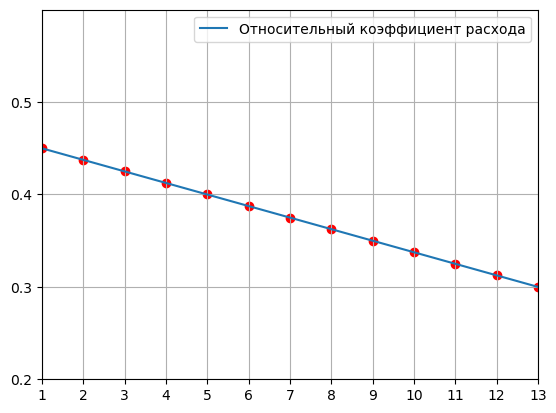

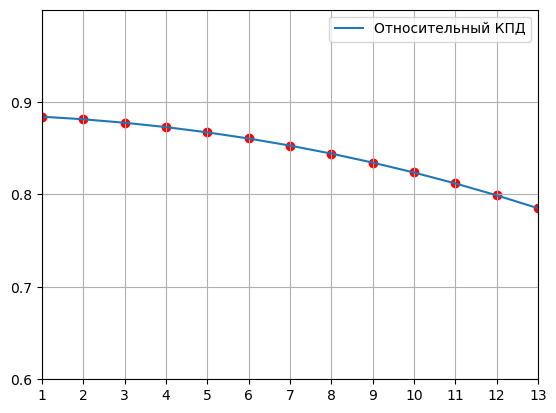

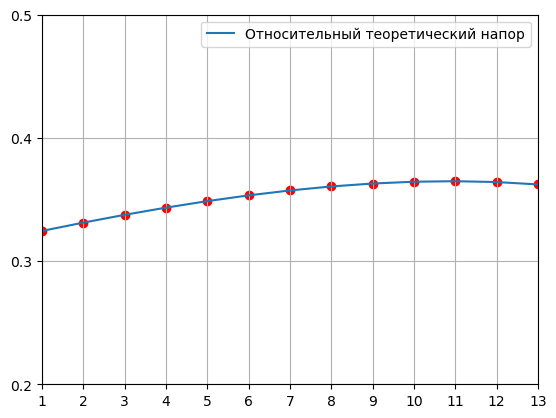

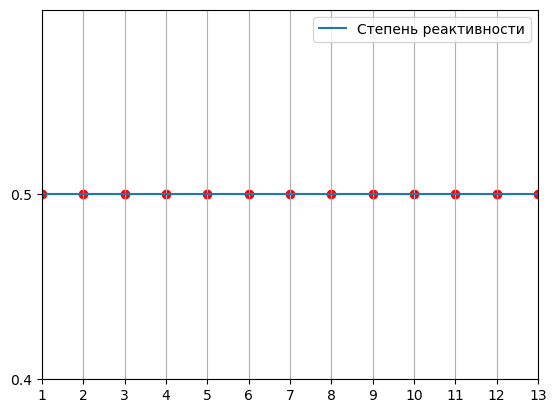

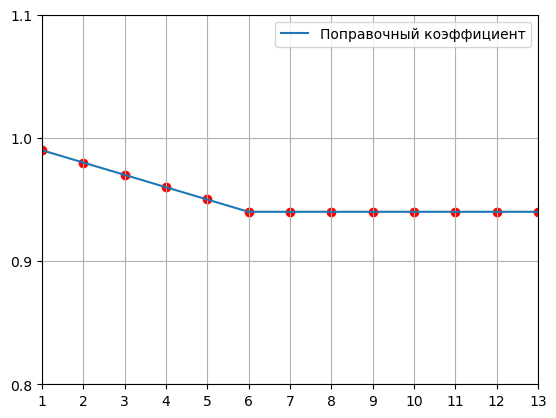

In [389]:
def plot_results(x, y, label_name):
    ylim_min = math.floor(min(y)*10)/10-0.1
    ylim_max = math.ceil(max(y)*10)/10+0.1
    plt.plot(x, y, label=label_name)
    plt.scatter(x, y, color="red")
    plt.xlim(1,max(x))
    plt.ylim(ylim_min, ylim_max)
    plt.xticks(np.arange(1, max(x)+1, 1))
    plt.yticks(np.arange(ylim_min, ylim_max, 0.1))
    plt.grid(True) # Добавление сетки
    plt.legend()
    plt.show()

R_ср1_list = np.linspace(R_ср1, R_ср1, N)  # Создаем массив из N элементов, все равные R_ср1
Kh = np.concatenate([
    np.linspace(0.99, 0.94, 6),
    np.full((N-6), 0.94)
])

plot_results(N_list, c_a_отн, "Относительный коэффициент расхода")
plot_results(N_list, η_ад_полн_result, "Относительный КПД")
plot_results(N_list, Hт_отн_result, "Относительный теоретический напор")
plot_results(N_list, R_ср1_list, "Степень реактивности")
plot_results(N_list, Kh, "Поправочный коэффициент")

In [390]:
# Расчет ВНА
# Коэффициент сохранения полного давления в ВНА
print(f"""
    σ_вх = {σ_вх:.4f} - коэффициент сохранения полного давления в ВНА
    Pa_полн = {Pа_полн:.2f} Па - полное давление на входе в ВНА
    P1_полн = {P1_полн:.2f} Па - полное давление на выходе из ВНА
    c_1u_отн = {c_1u_отн:.4f} - безразмерная окружная составляющая абсолютной скорости на выходе из ВНА""")

# Направление абсолютной скорости на входе в ВНА
α_1_вна = math.radians(90)
α_2_вна = (math.atan(c_а1_отн / c_1u_отн))

print(f"""
    α_1_вна = {math.degrees(α_1_вна):.2f}° - направление абсолютной скорости на входе в ВНА
    α_2_вна = {math.degrees(α_2_вна):.2f}° - направление абсолютной скорости на выходе из ВНА
      """)


    σ_вх = 0.9938 - коэффициент сохранения полного давления в ВНА
    Pa_полн = 101300.00 Па - полное давление на входе в ВНА
    P1_полн = 100674.77 Па - полное давление на выходе из ВНА
    c_1u_отн = 0.2495 - безразмерная окружная составляющая абсолютной скорости на выходе из ВНА

    α_1_вна = 90.00° - направление абсолютной скорости на входе в ВНА
    α_2_вна = 61.00° - направление абсолютной скорости на выходе из ВНА
      


# Создание пустых списков для записи в них значений

In [391]:
c_a_отн_i_list = [] 
c_a_отн_i_plus_1_list = []  
Kh_i_list = []  
η_ад_полн_i_list = []  
d1_отн_i_list = []  
ρ1_i_list = [] 
U_k1_i_list = [] 
Hт_отн_i_list = []
T1_полн_i_list = []  
P1_полн_i_list = [] 
Hт_i_list = []  
L_z_i_list = []  
H_ад_i_list = [] 
ΔT_полн_i_list = [] 
T3_полн_i_list = []   
T1_полн_i_plus_1_list = [] 
π_полн_i_list = []  
P3_полн_i_list = []
P1_полн_i_plus_1_list = []  
a_кр_1_i_list = []    
a_кр_3_i_list = []  
r_ср1_отн_i_list = [] 
c_u1_отн_i_list = []  
α_1_i_list = []  
c_a1_i_list = []  
λ_1_i_list = []  
q_1_i_list = []  
F_1_i_list = []  
c_a3_отн_i_list = []  
c_a3_i_list = []  
λ_3_отн_i_list = []  
q_3_отн_i_list = []  
F_3_отн_i_list = []  
D_вт3_i_list = []  
d3_отн_i_list = []  
r_ср3_отн_i_list = []  
c_3u_отн_i_list = []  
α_3_отн_i_list = []  
λ_3_i_list = []  
q_3_i_list = []  
F_3_i_list = []  
r_ср2_отн_i_list = []  
c_u2_отн_i_list = []  
β_1_i_list = []  
c_a2_отн_i_list = []  
β_2_i_list = []  
α_2_i_list = []  
ε_рк_i_list = []  
α_3_i_list = []  
ε_на_i_list = []  
c_1_i_list = []  
ρ3_i_list = []  
W_1_i_list = []  
c_a2_i_list = []  
W_2_i_list = []  
c_2_i_list = []  
τ_1_i_list = []  
T_1_i_list = []  
a_1_i_list = []  
M_w1_i_list = []  
λ_c2_i_list = []  
T2_полн_i_list = []  
τ_2_i_list = []  
T_2_i_list = []  
a_2_i_list = []  
M_c2_ср_i_list = []  
D_вт1_i_list = []  
h_рк_i_list = []  
d2_отн_i_list = []  
D_ср_1_list = []  
D_ср_2_list = []  
D_ср_3_list = []  
D_вт2_i_list = []  
h_на_i_list = []  
h_на_3_i_list = [] 

In [ ]:
for i in range(N-1):
    c_a_отн_i = c_a_отн[i]  # Коэффициент расхода на входе в ступень
    c_a_отн_i_plus_1 = c_a_отн[i+1] # Коэффициент расхода на выходе из ступени
    Kh_i = Kh[i]    # Поправочный коэффициент для i-й ступени
    η_ад_полн_i = η_ад_полн_result[i]   # Адиабатический КПД для i-й ступени
    d1_отн_i = d1_отн   # Относительный диаметр для i-й ступени
    ρ1_i = ρ1   # Плотность для i-й ступени
    U_k1_i = math.cbrt((G_в * n**2)/(math.pi * c_а1_отн * ρ1 * (1 - d1_отн**2)))    # Окружная скорость для i-й ступени
    Hт_отн_i = Hт_отн_result[i]  # Относительный теоретический напор для i-й ступени
    if i == 0: 
        T1_полн_i = T1_полн # Температура на входе в первую ступень
        P1_полн_i = P1_полн
    else:
        T1_полн_i = T1_полн_i_plus_1 # Температура на входе в i-ю ступень
        P1_полн_i = P1_полн_i_plus_1 # Полное давление на входе в i-ю ступень
        
        
    # Теоретический напор для i-й ступени:
    Hт_i = Hт_отн_i * (U_k1_i**2)
    
    # Действительная работа сжатия для i-й ступени:
    L_z_i = Kh_i * Hт_i
    
    # Адиабатическая работа сжатия для i-й ступени:
    H_ад_i = L_z_i * η_ад_полн_i
    
    # Повышение полной температуры в ступени:
    ΔT_полн_i = L_z_i / c_p # с_р в каждой ступени разный т.к. меняется температура
    
    # Полная температура на выходе из ступени:
    T3_полн_i = T1_полн_i + ΔT_полн_i
    T1_полн_i_plus_1 = T3_полн_i    # Температура на выходе становится температурой на входе в следующую ступень
    
    # Степень повышения полного давления:
    π_полн_i = (1 + (H_ад_i / (c_p * T1_полн_i)))**(k/(k-1))
    
    # Полное давление на выходе из ступени:
    P3_полн_i = P1_полн_i * π_полн_i 
    P1_полн_i_plus_1 = P3_полн_i    # Полное давление на выходе становится полным давлением на входе в следующую ступень
    
    # Критическая скорость потока на входе и выходе:
    a_кр_1_i = math.sqrt((2*k/(k+1))*R_в*T1_полн_i)
    a_кр_3_i = math.sqrt((2*k/(k+1))*R_в*T3_полн_i)
    
    # Средний радиус на входе в i-ю ступень:
    r_ср1_отн_i = math.sqrt( (1 + d1_отн_i**2) / 2)
    
    # Безразмерная окружная составляющая абсолютной скорости на входе в i-ю ступень:
    c_u1_отн_i = r_ср1_отн_i * (1 - R_ср1_list[i]) - (Hт_отн_i / (2 * r_ср1_отн_i))
    
    # Направление абсолютной скорости на входе
    α_1_i = α_2_вна
    
    # Приведенная скорость на входе
    c_a1_i = c_a_отн_i * U_k1_i
    λ_1_i = c_a1_i / (math.sin(α_1_i) * a_кр_1_i)
    
    # ГДФ расхода
    q_1_i = ((k+1)/2)**(1/(k-1)) * λ_1_i * (1 - (k-1)/(k+1)*λ_1_i**2)**(1/(k-1))
    
    # Кольцевая площадь на входе в ступень
    F_1_i = (G_в * math.sqrt(R_в * T1_полн_i)) / (β * P1_полн_i * q_1_i * math.sin(α_1_i))

    # Кольцевая площадь на выходе из ступени F3
    c_a3_отн_i = c_a_отн_i_plus_1
    c_a3_i = c_a3_отн_i * U_k1_i
    λ_3_отн_i = c_a3_i / (math.sin(α_1_i) * a_кр_3_i)
    q_3_отн_i = ((k+1)/2)**(1/(k-1)) * λ_3_отн_i * (1 - (k-1)/(k+1)*λ_3_отн_i**2)**(1/(k-1))
    F_3_отн_i = F_1_i * ((q_1_i * P1_полн_i) / (q_3_отн_i * P3_полн_i)) * math.sqrt(T3_полн_i / T1_полн_i)
    
    # Относительный диаметр втулки на выходе из ступени d3отн в первом прибляж для принятой ф. проточной части Dk = const
    # D.вт3 - диаметр периферии на выходе из i ступени
    D_вт3_i = math.sqrt(D_к1**2 - ((4 * F_3_отн_i) / math.pi))
    d3_отн_i = D_вт3_i / D_к1
    r_ср3_отн_i = math.sqrt( (1 + d3_отн_i**2) / 2)
    
    # Окружная состовляющая абсолютной скорости на выходе
    c_3u_отн_i = r_ср3_отн_i * (1 - R_ср1_list[i+1]) - (Hт_отн_result[i+1] / (2 * r_ср3_отн_i))
    
    # Направление абсолютной скорости на выходе
    α_3_отн_i = math.atan(c_a3_отн_i / c_3u_отн_i)

    # Приведенная скорость на выходе
    λ_3_i = c_a3_i / (math.sin(α_3_отн_i) * a_кр_3_i)
    
    # Действительная кольцевая площадь на выходе из ступени
    q_3_i = ((k+1)/2)**(1/(k-1)) * λ_3_i * (1 - (k-1)/(k+1)*λ_3_i**2)**(1/(k-1))
    F_3_i = F_3_отн_i * (q_3_отн_i / q_3_i)
    
    # Действительный отн. диаметр втулки на выходе из ступени для Dk=const
    D_вт3_i = math.sqrt(D_к1**2 - ((4 * F_3_i) / math.pi))
    d3_отн_i = D_вт3_i / D_к1
    
    # Относительный средний радиус на выходе из ступени
    r_ср3_отн_i = math.sqrt( (1 + d3_отн_i**2) / 2)
    
    # Окружная состовляющая абсолютной скорости на выходе
    c_3u_отн_i = r_ср3_отн_i * (1 - R_ср1_list[i+1]) - (Hт_отн_result[i+1] / (2 * r_ср3_отн_i))
    
    # Относительный средний радиус на выходе из рабочего колеса
    r_ср2_отн_i = (r_ср1_отн_i + r_ср3_отн_i) / 2
    
    # Безразмерная окружная составляющая абсолютной скорости на выходе из рабочего колеса
    c_u2_отн_i = (1 / r_ср2_отн_i) * (Hт_отн_i + c_u1_отн_i * r_ср1_отн_i)
    
    # Углы потока в относительном движении
    β_1_i = math.atan((c_a_отн_i / (r_ср1_отн_i- c_u1_отн_i)))
    c_a2_отн_i = (c_a_отн_i + c_a_отн_i_plus_1) / 2
    β_2_i = math.atan((c_a2_отн_i / (r_ср2_отн_i- c_u2_отн_i)))
    
    # Направление потока в абсолютном движении после рабочего колеса
    α_2_i = math.atan(c_a2_отн_i / c_u2_отн_i)
    
    # Углы поворота потока в средних сечениях лопаток РК и НА
    ε_рк_i = β_2_i - β_1_i
    
    # Направление потока в абсолютном движении после НА
    α_3_i = math.atan(c_a3_отн_i / c_3u_отн_i)
    ε_на_i = α_3_i - α_2_i
    λ_3_i = c_a3_i / (math.sin(α_3_i) * a_кр_3_i)
    
    # Абсолютная скорость на входе в РК
    c_1_i = U_k1_i * math.sqrt(c_a_отн_i**2 + c_u1_отн_i**2)
    
    # Плотность заторможенного потока на выходе из ступени
    ε_3_i = (1 - (k-1)/(k+1)*λ_3_i**2)**(1/(k-1))
    ρ3_i = ((P3_полн_i) / (R_в * T3_полн_i)) * ε_3_i
    
    # Относительная скорость на среднем радиусе на входе в РК
    W_1_i = c_a1_i / math.sin(β_1_i)
    c_a2_i = c_a2_отн_i * U_k1_i
    
    # Относительная скорость на среднем радиусе на входе в НА
    W_2_i = c_a2_i / math.sin(β_2_i)
    
    # Абсолютная скорость на среднем радиусе на входе в НА
    c_2_i = c_a2_i / math.sin(α_2_i)
    
    # ГДФ температуры на входе в РК
    τ_1_i = (1 - (λ_1_i**2)*((k-1)/(k+1)))
    
    
    # Статическая температура перед РК
    T_1_i = T1_полн_i * τ_1_i
    
    # Скорость звука на входе в РК
    a_1_i = math.sqrt(k * R_в * T_1_i)
    
    # Число Маха по относительной скорости на входе в РК
    M_w1_i = W_1_i / a_1_i
    
    # Приведенная скорость перед НА
    λ_c2_i = c_2_i / a_кр_3_i
    
    # Статическая температура перед НА
    T2_полн_i = T3_полн_i
    τ_2_i = (1 - (λ_c2_i**2)*((k-1)/(k+1)))
    T_2_i = T2_полн * τ_2_i
    
    # Скорость звука на входе в НА
    a_2_i = math.sqrt(k * R_в * T_2_i)
    
    # Число Маха по абсолютной скорости на входе в НА
    M_c2_ср_i = c_2_i / a_2_i
    
    # Высота лопаток рабочего колеса
    D_вт1_i = D_к1 * d1_отн_i
    h_рк_i = 0.5 * (D_к1 - D_вт1_i)
    
    # Относительный диаметр втулки на выходе из РК
    d2_отн_i = math.sqrt(2 * (r_ср2_отн_i**2) - 1)
    D_ср_1 = D_к1 * r_ср1_отн_i
    D_ср_2 = D_к1 * r_ср2_отн_i
    D_ср_3 = D_к1 * r_ср3_отн_i
    
    # Периферийный диаметр на выходе из РК
    D_вт2_i = D_к1 * d2_отн_i
    D_вт1_i = D_к1 * d1_отн_i
    
    # Высота лопаток НА
    h_на_i = 0.5 * (D_к1 - D_вт2_i)
    h_на_3_i = 0.5 * (D_к1 - D_вт3_i)

    # Сохранение всех значений ниже
    c_a_отн_i_list.append(c_a_отн_i)  
    c_a_отн_i_plus_1_list.append(c_a_отн_i_plus_1)  
    Kh_i_list.append(Kh_i)  
    η_ад_полн_i_list.append(η_ад_полн_i)  
    d1_отн_i_list.append(d1_отн_i)  
    ρ1_i_list.append(ρ1_i)  
    U_k1_i_list.append(U_k1_i)  
    Hт_отн_i_list.append(Hт_отн_i)  
    T1_полн_i_list.append(T1_полн_i)  
    P1_полн_i_list.append(P1_полн_i)  
    Hт_i_list.append(Hт_i)  
    L_z_i_list.append(L_z_i)  
    H_ад_i_list.append(H_ад_i)  
    ΔT_полн_i_list.append(ΔT_полн_i)  
    T3_полн_i_list.append(T3_полн_i)  
    T1_полн_i_plus_1_list.append(T1_полн_i_plus_1)  
    π_полн_i_list.append(π_полн_i)  
    P3_полн_i_list.append(P3_полн_i)  
    P1_полн_i_plus_1_list.append(P1_полн_i_plus_1)  
    a_кр_1_i_list.append(a_кр_1_i)  
    a_кр_3_i_list.append(a_кр_3_i)  
    r_ср1_отн_i_list.append(r_ср1_отн_i)  
    c_u1_отн_i_list.append(c_u1_отн_i)  
    α_1_i_list.append(α_1_i)  
    c_a1_i_list.append(c_a1_i)  
    λ_1_i_list.append(λ_1_i)  
    q_1_i_list.append(q_1_i)  
    F_1_i_list.append(F_1_i)  
    c_a3_отн_i_list.append(c_a3_отн_i)  
    c_a3_i_list.append(c_a3_i)  
    λ_3_отн_i_list.append(λ_3_отн_i)  
    q_3_отн_i_list.append(q_3_отн_i)  
    F_3_отн_i_list.append(F_3_отн_i)  
    D_вт3_i_list.append(D_вт3_i)  
    d3_отн_i_list.append(d3_отн_i)  
    r_ср3_отн_i_list.append(r_ср3_отн_i)  
    c_3u_отн_i_list.append(c_3u_отн_i)  
    α_3_отн_i_list.append(α_3_отн_i)  
    λ_3_i_list.append(λ_3_i)  
    q_3_i_list.append(q_3_i)  
    F_3_i_list.append(F_3_i)  
    r_ср2_отн_i_list.append(r_ср2_отн_i)  
    c_u2_отн_i_list.append(c_u2_отн_i)  
    β_1_i_list.append(β_1_i)  
    c_a2_отн_i_list.append(c_a2_отн_i)  
    β_2_i_list.append(β_2_i)  
    α_2_i_list.append(α_2_i)  
    ε_рк_i_list.append(ε_рк_i)  
    α_3_i_list.append(α_3_i)  
    ε_на_i_list.append(ε_на_i)  
    c_1_i_list.append(c_1_i)  
    ρ3_i_list.append(ρ3_i)  
    W_1_i_list.append(W_1_i)  
    c_a2_i_list.append(c_a2_i)  
    W_2_i_list.append(W_2_i)  
    c_2_i_list.append(c_2_i)  
    τ_1_i_list.append(τ_1_i)  
    T_1_i_list.append(T_1_i)  
    a_1_i_list.append(a_1_i)  
    M_w1_i_list.append(M_w1_i)  
    λ_c2_i_list.append(λ_c2_i)  
    T2_полн_i_list.append(T2_полн_i)  
    τ_2_i_list.append(τ_2_i)  
    T_2_i_list.append(T_2_i)  
    a_2_i_list.append(a_2_i)  
    M_c2_ср_i_list.append(M_c2_ср_i)  
    D_вт1_i_list.append(D_вт1_i)  
    h_рк_i_list.append(h_рк_i)  
    d2_отн_i_list.append(d2_отн_i)  
    D_ср_1_list.append(D_ср_1)  
    D_ср_2_list.append(D_ср_2)  
    D_ср_3_list.append(D_ср_3)  
    D_вт2_i_list.append(D_вт2_i)  
    h_на_i_list.append(h_на_i)  
    h_на_3_i_list.append(h_на_3_i)

# Степень повышения полного давления в лопаточном аппарате:
π_ла_полн = P3_полн_i_list[len(P3_полн_i_list)-1] / P1_полн_i_list[0]
η_ла_полн = ((T1_полн_i_list[0] * ((π_ла_полн ** ((k-1)/k)) - 1)) / (T3_полн_i_list[len(T3_полн_i_list)-1] - T1_полн_i_list[0]))

# Степень повышения полного давления в компрессоре
π_к_полн = π_ла_полн * (1 / (1 + ξ_вх * (k/(k+1)) * ε_вх * λ_вх**2)) * (1 - ξ_вых * (k/(k+1)) * ε_вых * λ_вых**2)

# КПД компрессора
η_к_полн = ((T1_полн_i_list[0] * ((π_к_полн ** ((k-1)/k)) - 1)) / (T3_полн_i_list[len(T3_полн_i_list)-1] - T1_полн_i_list[0]))


In [ ]:
η_к_полн 

np.float64(0.7963680423150544)

In [394]:
# Список всех имён переменных‑списков
list_names = [
    "c_u1_отн_i_list","α_1_i_list","c_a1_i_list","λ_1_i_list",
    "q_1_i_list","F_1_i_list","c_a3_отн_i_list","c_a3_i_list",
    "λ_3_отн_i_list","q_3_отн_i_list","F_3_отн_i_list","D_вт3_i_list",
    "d3_отн_i_list","r_ср3_отн_i_list","c_3u_отн_i_list","α_3_отн_i_list",
    "λ_3_i_list","q_3_i_list","F_3_i_list","r_ср2_отн_i_list",
    "c_u2_отн_i_list","β_1_i_list","c_a2_отн_i_list","β_2_i_list",
    "α_2_i_list","ε_рк_i_list","α_3_i_list","ε_на_i_list",
    "c_1_i_list","ρ3_i_list","W_1_i_list","c_a2_i_list",
    "W_2_i_list","c_2_i_list","τ_1_i_list","T_1_i_list",
    "a_1_i_list","M_w1_i_list","λ_c2_i_list","T2_полн_i_list",
    "τ_2_i_list","T_2_i_list","a_2_i_list","M_c2_ср_i_list",
    "D_вт1_i_list","h_рк_i_list","d2_отн_i_list",
    "D_ср_1_list","D_ср_2_list","D_ср_3_list",
    "D_вт2_i_list","h_на_i_list","h_на_3_i_list"
]

# Формируем словарь {короткое_имя: список_значений}
data = {}
for name in list_names:
    # получаем объект по имени (globals())
    lst = globals().get(name, [])
    data[name.rstrip('_list')] = lst          # убираем суффикс _list для названия колонки

# ──────────────────────────────────────────────────────
# 3️⃣ Выравниваем длину всех списков (чтобы DataFrame не ругался)
# ──────────────────────────────────────────────────────
max_len = max(len(col) for col in data.values())
for key, col in data.items():
    if len(col) < max_len:
        data[key] = col + [np.nan]*(max_len - len(col))

# ──────────────────────────────────────────────────────
# 4️⃣ Создаём DataFrame
# ──────────────────────────────────────────────────────
df = pd.DataFrame(data)

# ──────────────────────────────────────────────────────
# 5️⃣ Настраиваем вывод (по желанию)
# ──────────────────────────────────────────────────────
pd.set_option('display.max_columns', None)   # показывать все столбцы
pd.set_option('display.max_rows',    200)   # ограничить количество строк (чтобы не «зависать»)
pd.set_option('display.float_format', lambda x: f'{x: .4g}')

# ──────────────────────────────────────────────────────
# 6️⃣ Выводим таблицу в ячейке ноутбука
# ──────────────────────────────────────────────────────
display(df)            # либо просто написать `df` в отдельной ячейке

# ──────────────────────────────────────────────────────
# 7️⃣ (Опционально) сохраняем в файл
# ──────────────────────────────────────────────────────
df.to_excel('расчет_ступеней.xlsx', index=False)
# df.to_csv('расчет_ступеней.csv', index=False)

,c_u1_отн,α_1,c_a1,λ_1,q_1,F_1,c_a3_отн,c_a3,λ_3_отн,q_3_отн,F_3_отн,D_вт3,d3_отн,r_ср3_отн,c_3u_отн,α_3_отн,λ_3,q_3,F_3,r_ср2_отн,c_u2_отн,β_1,c_a2_отн,β_2,α_2,ε_рк,α_3,ε_на,c_1,ρ3,W_1,c_a2,W_2,c_2,τ_1,T_1,a_1,M_w1,λ_c2,T2_полн,τ_2,T_2,a_2,M_c2_ср,D_вт1,h_рк,d2_отн,D_ср_1,D_ср_2,D_ср_3,D_вт2,h_на,h_на_3
0,0.1678,1.065,150.7,0.5547,0.7671,0.3652,0.4375,146.6,0.5086,0.7185,0.2869,0.4226,0.5681,0.8132,0.203,1.129,0.4903,0.7002,0.2944,0.7874,0.5743,0.6485,0.4437,1.123,0.6578,0.4746,1.136,0.4785,160.9,1.407,249.6,148.7,164.9,243.1,0.9487,273.2,331.6,0.7527,0.7378,323.8,0.9093,644.8,509.3,0.4773,0.2976,0.2232,0.4899,0.5666,0.5858,0.605,0.3645,0.1897,0.1607
1,0.1633,1.065,146.6,0.5086,0.7185,0.2869,0.425,142.4,0.4685,0.6733,0.2323,0.5065,0.6808,0.8554,0.2304,1.073,0.4661,0.6707,0.2332,0.8085,0.5635,0.6314,0.4313,1.054,0.6532,0.4227,1.074,0.4208,156.4,1.776,248.3,144.5,166.2,237.7,0.9569,309.9,353.1,0.7031,0.6842,360,0.922,653.8,512.9,0.4635,0.2976,0.2232,0.5544,0.5666,0.6015,0.6364,0.4124,0.1658,0.1187
2,0.1592,1.065,142.4,0.4685,0.6733,0.2323,0.4125,138.2,0.4333,0.6313,0.1929,0.5582,0.7503,0.884,0.2478,1.032,0.4421,0.6412,0.19,0.8228,0.5576,0.6144,0.4187,1.006,0.6442,0.3918,1.03,0.3857,152,2.194,247,140.3,166.1,233.6,0.9634,346.9,373.6,0.6611,0.6406,396.6,0.9316,660.6,515.6,0.4531,0.2976,0.2232,0.595,0.5666,0.6121,0.6577,0.4426,0.1507,0.09288
3,0.1554,1.065,138.2,0.4333,0.6313,0.1929,0.4,134,0.4019,0.5922,0.1637,0.5931,0.7973,0.9043,0.2594,0.9998,0.419,0.6122,0.1584,0.833,0.5543,0.5975,0.4062,0.9695,0.6325,0.372,0.9955,0.363,147.7,2.66,245.6,136.1,165,230.2,0.9687,384.1,393.1,0.6248,0.6039,433.3,0.9392,666,517.7,0.4447,0.2976,0.2232,0.6226,0.5666,0.6197,0.6728,0.4632,0.1404,0.07541
4,0.1519,1.065,134,0.4019,0.5922,0.1637,0.3875,129.8,0.3738,0.5559,0.1416,0.6181,0.8308,0.9193,0.2675,0.972,0.3972,0.5843,0.1347,0.8404,0.5525,0.5806,0.3938,0.9394,0.6192,0.3587,0.9666,0.3474,143.3,3.17,244.3,131.9,163.4,227.3,0.9731,421.7,411.9,0.593,0.5723,470.3,0.9454,670.4,519.4,0.4376,0.2976,0.2232,0.6424,0.5666,0.6252,0.6839,0.4779,0.133,0.06295
5,0.1488,1.065,129.8,0.3738,0.5559,0.1416,0.375,125.6,0.3483,0.522,0.1244,0.6365,0.8556,0.9306,0.2733,0.9471,0.3769,0.5578,0.1165,0.8461,0.5516,0.5639,0.3812,0.913,0.6048,0.3491,0.941,0.3361,139.1,3.722,242.9,127.7,161.4,224.6,0.9767,459.3,429.9,0.565,0.5446,507.3,0.9506,674.1,520.8,0.4313,0.2976,0.2232,0.6571,0.5666,0.6294,0.6923,0.4888,0.1276,0.05371
6,0.1462,1.065,125.6,0.3483,0.522,0.1244,0.3625,121.4,0.3249,0.4902,0.1109,0.6508,0.8748,0.9395,0.2778,0.9235,0.358,0.5326,0.1021,0.8505,0.551,0.5473,0.3688,0.8887,0.5898,0.3414,0.9168,0.3271,134.8,4.317,241.4,123.5,159.1,222.1,0.9798,497.1,447.2,0.5398,0.5197,544.8,0.955,677.2,522,0.4255,0.2976,0.2232,0.6684,0.5666,0.6327,0.6989,0.4973,0.1233,0.04659
7,0.1441,1.065,121.4,0.3249,0.4902,0.1109,0.35,117.2,0.3033,0.4603,0.1001,0.662,0.8898,0.9465,0.2815,0.9005,0.3404,0.5089,0.09052,0.854,0.5506,0.5308,0.3562,0.8654,0.5742,0.3345,0.8934,0.3192,130.7,4.953,239.9,119.3,156.8,219.7,0.9824,535.2,464.1,0.5169,0.4971,582.6,0.9588,679.9,523,0.4201,0.2976,0.2232,0.6773,0.5666,0.6354,0.7042,0.5039,0.12,0.04099
8,0.1425,1.065,117.2,0.3033,0.4603,0.1001,0.3375,113.1,0.2834,0.4322,0.09135,0.6709,0.9019,0.9522,0.2847,0.8775,0.3243,0.4866,0.08114,0.8569,0.5502,0.5146,0.3438,0.8423,0.5584,0.3278,0.87,0.3115,126.6,5.624,238.2,115.2,154.3,217.3,0.9847,573.7,480.4,0.4959,0.4764,620.7,0.9622,682.3,524,0.4148,0.2976,0.2232,0.6845,0.5666,0.6375,0.7084,0.5092,0.1174,0.03651
9,0.1415,1.065,113.1,0.2834,0.4322,0.09135,0.325,108.9,0.2649,0.4057,0.08433,0.6782,0.9116,0.9568,0.2878,0.8541,0.3094,0.4658,0.07344,0.8592,0.5496,0.4985,0.3312,0.8191,0.5424,0.3207,0.8461,0.3037,122.6,6.325,236.5,111,151.9,215,0.9866,612.4,496.4,0.4764,0.4573,658.9,0.9651,684.4,524.8,0.4096,0.2976,0.2232,0.6903,0.5666,0.6392,0.7118,0.5135,0.1152,0.03288
